In [2]:
import sys
if "ESP32_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [3]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import tensorflow as tf
import math

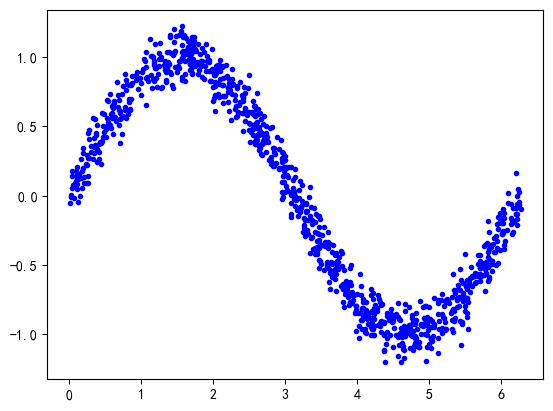

In [4]:
# 1. 生成模拟数据
# 生成从0到2派的数据，并将数据转换为np的float32的格式
x_values = np.random.uniform(low=0, high=2 * math.pi,
                             size=1000).astype(np.float32)
# 将数据随机排列
np.random.shuffle(x_values)

# 得到数据y
y_values = np.sin(x_values).astype(np.float32)

# 添加随机噪声
y_values += 0.1 * np.random.randn(*y_values.shape)

# 绘制图形
plt.plot(x_values, y_values, "b.")
plt.show()


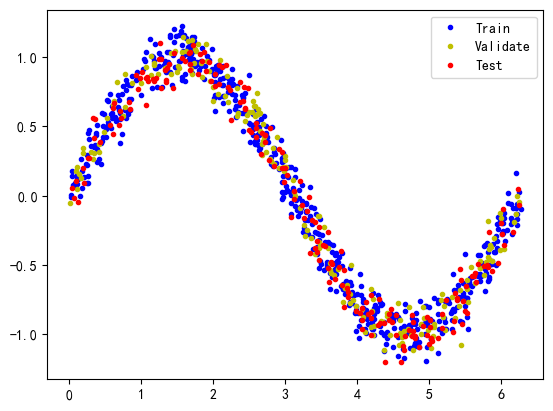

In [5]:
# 2. 拆分数据集
# 拆分数据集，将数据集分为训练集(60%)、测试集(20%)和验证集(20%)
TRAIN_SPLIT = int(0.6 * 1000)
TEST_SPLIT = int(0.2 * 1000 + TRAIN_SPLIT)

# 拆分数据集
x_train, x_validate, x_test = np.split(x_values, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_validate, y_test = np.split(y_values, [TRAIN_SPLIT, TEST_SPLIT])

# 绘制图形
plt.plot(x_train, y_train, "b.", label="Train")
plt.plot(x_validate, y_validate, "y.", label="Validate")
plt.plot(x_test, y_test, "r.", label="Test")
# 图像加图例
plt.legend()
plt.show()


In [6]:
# 3. 创建模型网络
model = tf.keras.Sequential()

# First layer takes a scalar input and feeds it through 16 "neurons". The
# neurons decide whether to activate based on the 'relu' activation function.
model.add(tf.keras.layers.Dense(16, activation='relu', input_shape=(1,)))

# The new second and third layer will help the network learn more complex
# representations
model.add(tf.keras.layers.Dense(16, activation='relu'))

# Final layer is a single neuron, since we want to output a single value
model.add(tf.keras.layers.Dense(1))

# Compile the model using the standard 'adam' optimizer and the mean squared
# error or 'mse' loss function for regression.
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# 打印模型参数
model.summary()


d:\conda_envs\ESP32_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 4. 模型训练
model.fit(x_values,
          y_values,
          epochs=400,
          validation_split=0.2,
          batch_size=64,
          verbose=2)


Epoch 1/400
13/13 - 1s - 68ms/step - loss: 0.4691 - mae: 0.5989 - val_loss: 0.4207 - val_mae: 0.5526
Epoch 2/400
13/13 - 0s - 6ms/step - loss: 0.4170 - mae: 0.5438 - val_loss: 0.3934 - val_mae: 0.5413
Epoch 3/400
13/13 - 0s - 6ms/step - loss: 0.3896 - mae: 0.5386 - val_loss: 0.3767 - val_mae: 0.5392
Epoch 4/400
13/13 - 0s - 6ms/step - loss: 0.3650 - mae: 0.5168 - val_loss: 0.3473 - val_mae: 0.5091
Epoch 5/400
13/13 - 0s - 6ms/step - loss: 0.3427 - mae: 0.5012 - val_loss: 0.3304 - val_mae: 0.5015
Epoch 6/400
13/13 - 0s - 8ms/step - loss: 0.3239 - mae: 0.4896 - val_loss: 0.3087 - val_mae: 0.4828
Epoch 7/400
13/13 - 0s - 9ms/step - loss: 0.3056 - mae: 0.4748 - val_loss: 0.2917 - val_mae: 0.4707
Epoch 8/400
13/13 - 0s - 7ms/step - loss: 0.2888 - mae: 0.4633 - val_loss: 0.2769 - val_mae: 0.4608
Epoch 9/400
13/13 - 0s - 5ms/step - loss: 0.2738 - mae: 0.4517 - val_loss: 0.2600 - val_mae: 0.4462
Epoch 10/400
13/13 - 0s - 6ms/step - loss: 0.2622 - mae: 0.4438 - val_loss: 0.2443 - val_mae: 0.432

In [10]:
import tensorflow as tf
import pathlib

# 假设 model 已经训练完成
# model.fit(...)

# ----------------- 1. 直接转换 Keras 模型 -----------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = []               # 不做任何优化
converter.target_spec.supported_types = [tf.float32]  # 使用 FP32

tflite_model = converter.convert()

# ----------------- 2. 保存 TFLite 文件 -----------------
tflite_model_file = pathlib.Path('model.tflite')
tflite_model_file.write_bytes(tflite_model)
print("FP32 TFLite 模型已保存为:", tflite_model_file)

# ----------------- 3. 生成 C++ 数组 -----------------
cc_file_path = pathlib.Path("model.cc")
with open(cc_file_path, "w", encoding="utf-8") as f:
    f.write('#include "model.h"\n\n')
    f.write("const unsigned char g_model[] = {\n")
    for i, b in enumerate(tflite_model):
        if i % 12 == 0:
            f.write("    ")
        f.write(f"0x{b:02x}, ")
        if (i + 1) % 12 == 0:
            f.write("\n")
    f.write("\n};\n\n")
    f.write(f"const int g_model_len = {len(tflite_model)};\n")

print(f"干净的 model.cc 已生成，长度 {len(tflite_model)} 字节")

INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmpsufcov95\assets


INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmpsufcov95\assets


Saved artifact at 'C:\Users\lxl\AppData\Local\Temp\tmpsufcov95'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2588356075088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2589191107024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2588356075856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2588356074896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2589193544400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2588356075472: TensorSpec(shape=(), dtype=tf.resource, name=None)
FP32 TFLite 模型已保存为: model.tflite
干净的 model.cc 已生成，长度 3164 字节
